# Nonlinear models

Peter Ralph

https://uodsci.github.io/dsci345

In [1]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.figsize'] = (15, 8)
import numpy as np
import pandas as pd
from dsci345 import pretty

rng = np.random.default_rng()

$$\renewcommand{\P}{\mathbb{P}} \newcommand{\E}{\mathbb{E}} \newcommand{\var}{\text{var}} \newcommand{\sd}{\text{sd}} \newcommand{\cov}{\text{cov}} \newcommand{\cor}{\text{cor}}$$
This is here so we can use `\P` and `\E` and `\var` and `\cov` and `\cor` and `\sd` in LaTeX below.

# When it's not straight lines, part 1

We've spent a fair bit of time on fitting *linear* relationships.
What about when they aren't linear?
For instance, what if the data seem to follow a (somewhat noisy) sine/cosine curve?

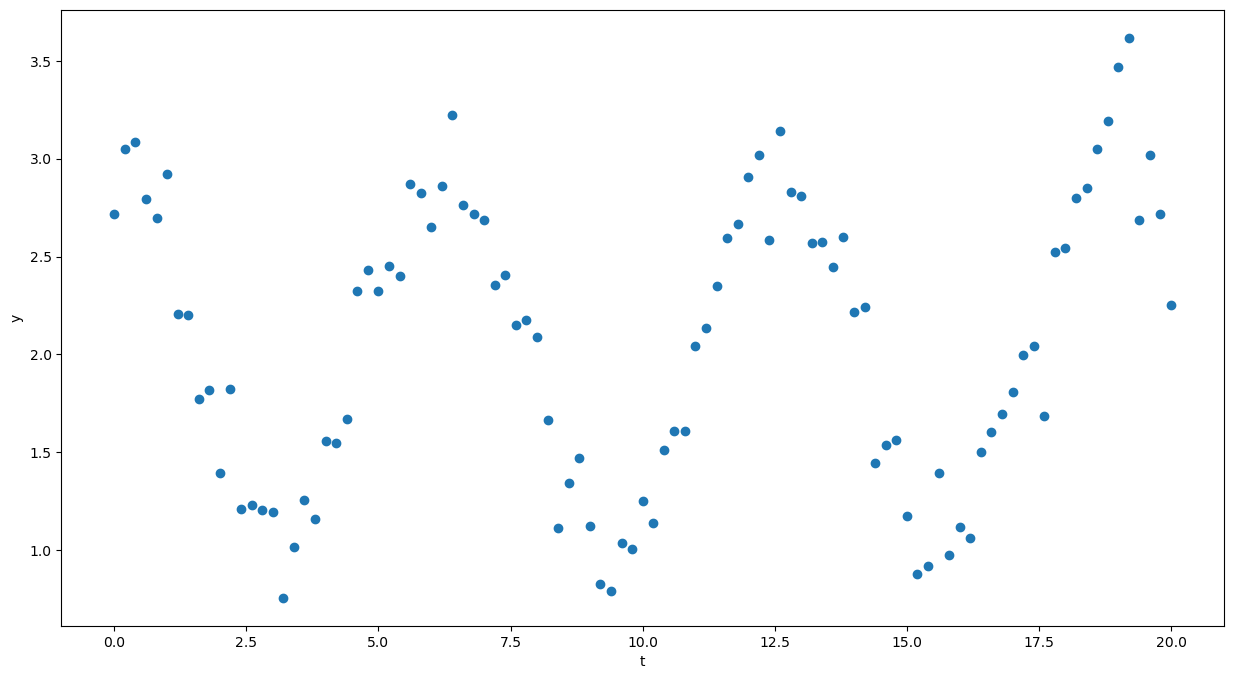

In [11]:
# plot 1
t = np.linspace(0, 20, 101)
y = 2 + np.cos(t) + rng.normal(scale=0.2, size=101)
plt.scatter(t, y); plt.xlabel("t"); plt.ylabel("y");

*Solution:* the data are of this form:
$$ y_i = a + b \cos(x_i) + \epsilon_i $$
... which *is* linear, in $\cos(x)$!

**Solution:** make a new variable that is $\cos(x)$.

**In class:** fit this.

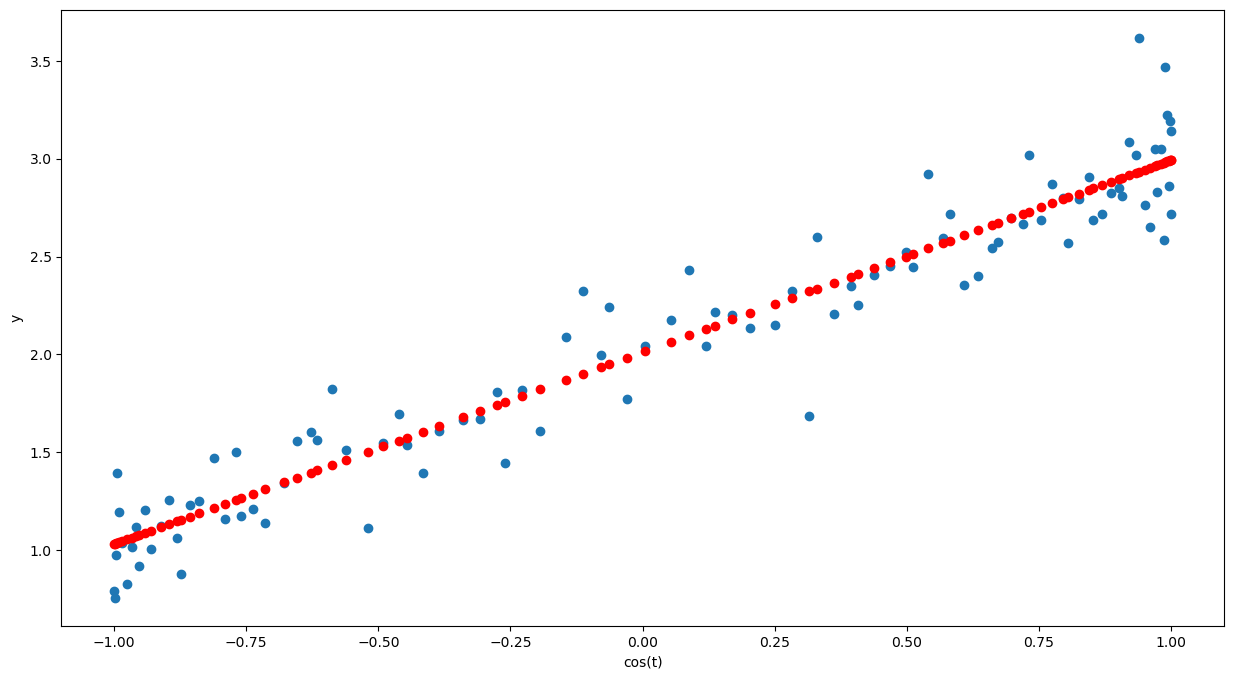

In [13]:
cor = np.corrcoef(y, np.cos(t))[0,1]
b = cor * np.std(y, ddof=1) / np.std(np.cos(t), ddof=1)
a = np.mean(y) - b * np.mean(np.cos(t))
yhat = a + b * np.cos(t)

fig, ax = plt.subplots()
ax.scatter(np.cos(t), y)
ax.scatter(np.cos(t), yhat, c='red')
ax.set_xlabel("cos(t)"); ax.set_ylabel("y");

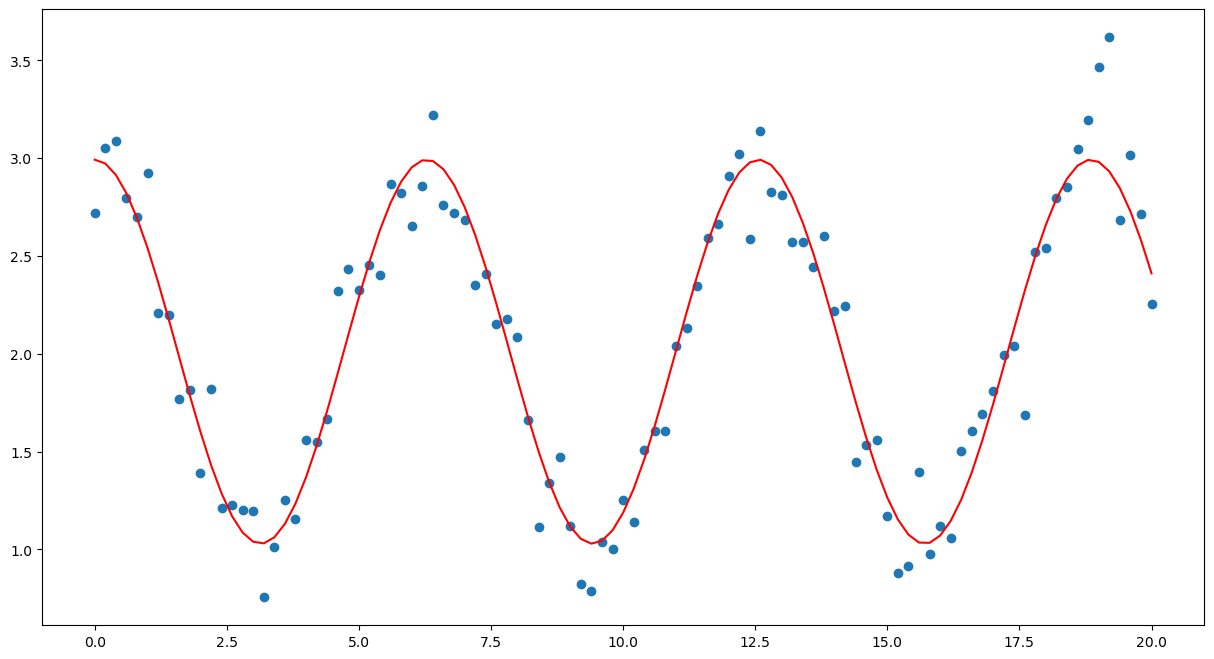

In [15]:
tt = np.linspace(np.min(t), np.max(t), 101)
yy = a + b * np.cos(tt)

fig, ax = plt.subplots()
ax.scatter(t, y)
ax.plot(tt, yy, c='red');

# Example: sines and cosines

Suppose we have measured the intensities of radio waves received from a nearby star.
The measured intensity at time $t_i$ is $y_i$, for $1 \le i \le n$.
We would like to fit a periodic form to the data, like:
$$
    y(t) = \sum_{j=0}^{k} \alpha_j \cos(\pi t / 2^j) + \beta_j \sin(\pi t / 2^j)  + \epsilon ,
$$
where $\epsilon$ is mean-zero noise.
How can we do this?

We can in fact transform this into a problem of fitting a linear model:
let $y = (y_1, \ldots, y_n)$
and define the matrix $X$ to be
$$
X =
\begin{bmatrix}
    \cos(\pi t_1)  & \sin(\pi t_1) & \cos(\pi t_1 / 2)  & \sin(\pi t_1 / 2) & \cdots & \cos(\pi t_1 / 2^k)  & \sin(\pi t_1 / 2^k) \\
    \cos(\pi t_2)  & \sin(\pi t_2) & \cos(\pi t_2 / 2)  & \sin(\pi t_2 / 2) & \cdots & \cos(\pi t_2 / 2^k)  & \sin(\pi t_2 / 2^k) \\
    \vdots & \vdots & & & & \vdots & \vdots \\
    \cos(\pi t_n)  & \sin(\pi t_n) & \cos(\pi t_n / 2)  & \sin(\pi t_n / 2) & \cdots & \cos(\pi t_n / 2^k)  & \sin(\pi t_2 / 2^k) 
\end{bmatrix}.
$$
Now, if we define $a = (\alpha_0, \beta_0, \alpha_1, \beta_1, \ldots, \alpha_k, \beta_k)$,
then our model is
$$ y = X a + \epsilon , $$
so we can solve the problem using the tools we've learned.

Let's try it out!
First, we'll simulate some data:

In [3]:
n = 150
true_coefs = [(1, 0), (3.2, 2.5), (0, 0), (10, 0)]
tvec = np.sort(rng.uniform(low=0, high=15, size=n))
mean_yvec = np.zeros(n)
for j, (alpha, beta) in enumerate(true_coefs):
    mean_yvec += alpha * np.cos(np.pi * tvec / 2**j) + beta * np.sin(np.pi * tvec / 2**j)
yvec = mean_yvec + rng.normal(scale=2.0, size=n)

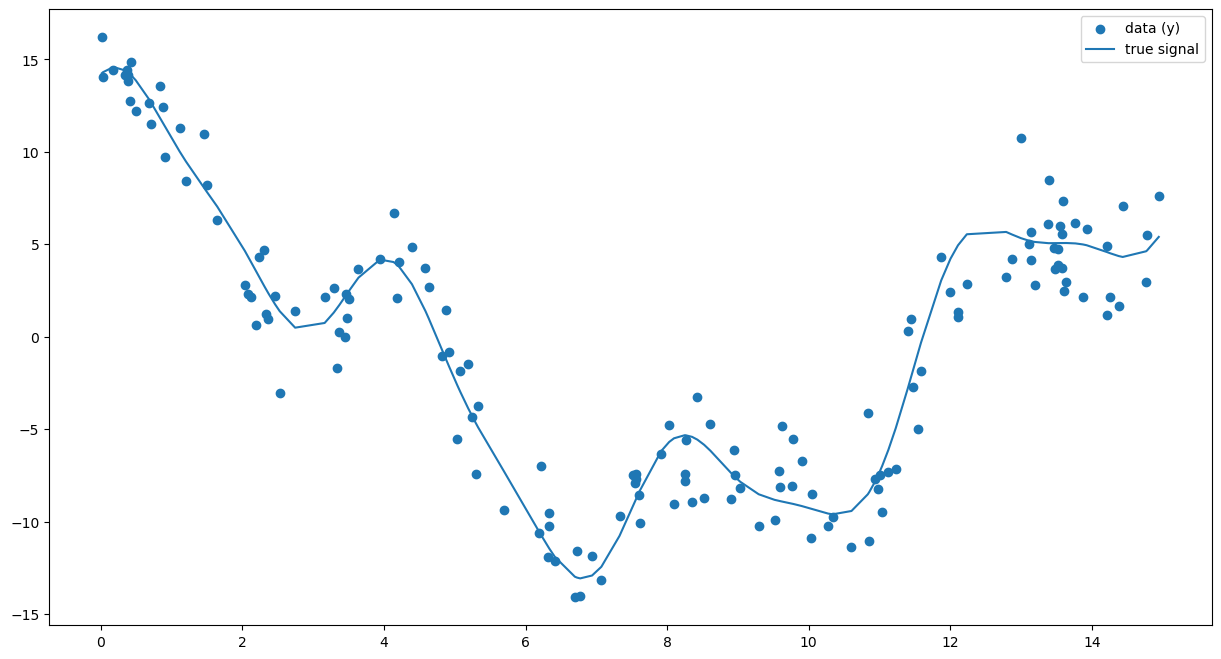

In [4]:
# plot 4
fig, ax = plt.subplots()
ax.scatter(tvec, yvec, label="data (y)")
ax.plot(tvec, mean_yvec, label="true signal")
ax.legend();

Now, we fit the model by least squares:

In [16]:
k = 5
X = np.array([
    [np.cos(np.pi * t / 2 ** j) for j in range(k+1)]
    + [np.sin(np.pi * t / 2 ** j) for j in range(k+1)] 
    for t in tvec
])
a_hat = np.linalg.solve(np.matmul(X.T, X), (X.T).dot(yvec))
y_hat = X.dot(a_hat)

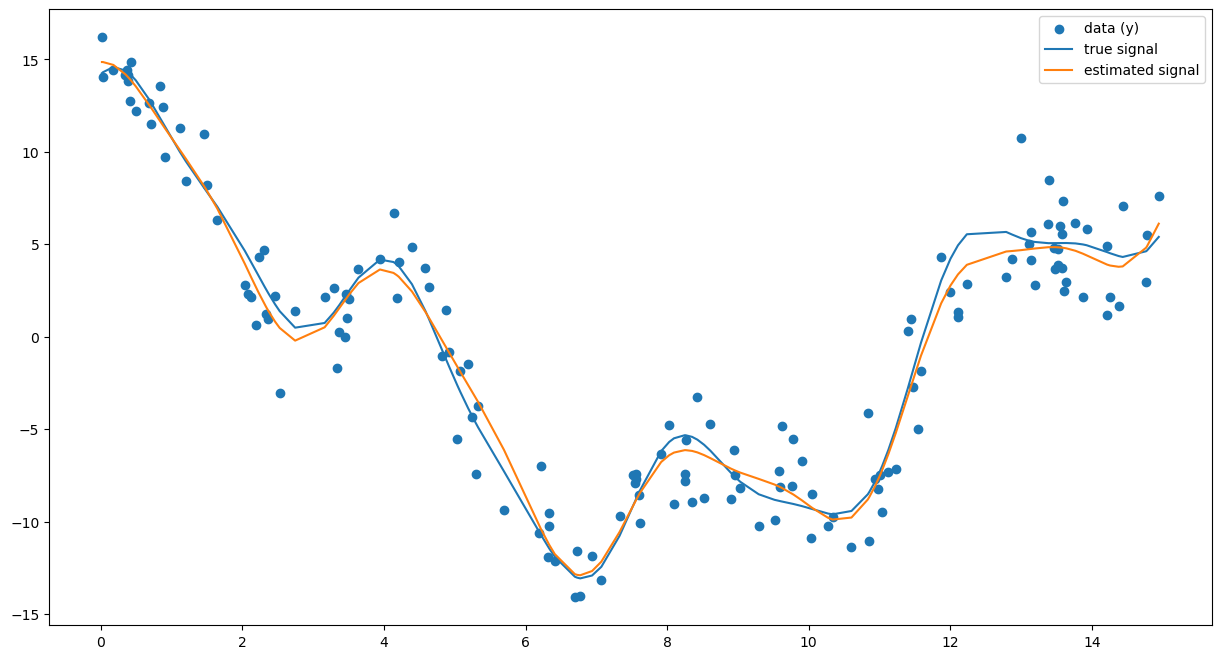

In [17]:
# plot 5
fig, ax = plt.subplots()
ax.scatter(tvec, yvec, label="data (y)")
ax.plot(tvec, mean_yvec, label="true signal")
ax.plot(tvec, y_hat, label="estimated signal")
ax.legend();

# When it's not straight lines, part 2

Okay, what if the data look like this?

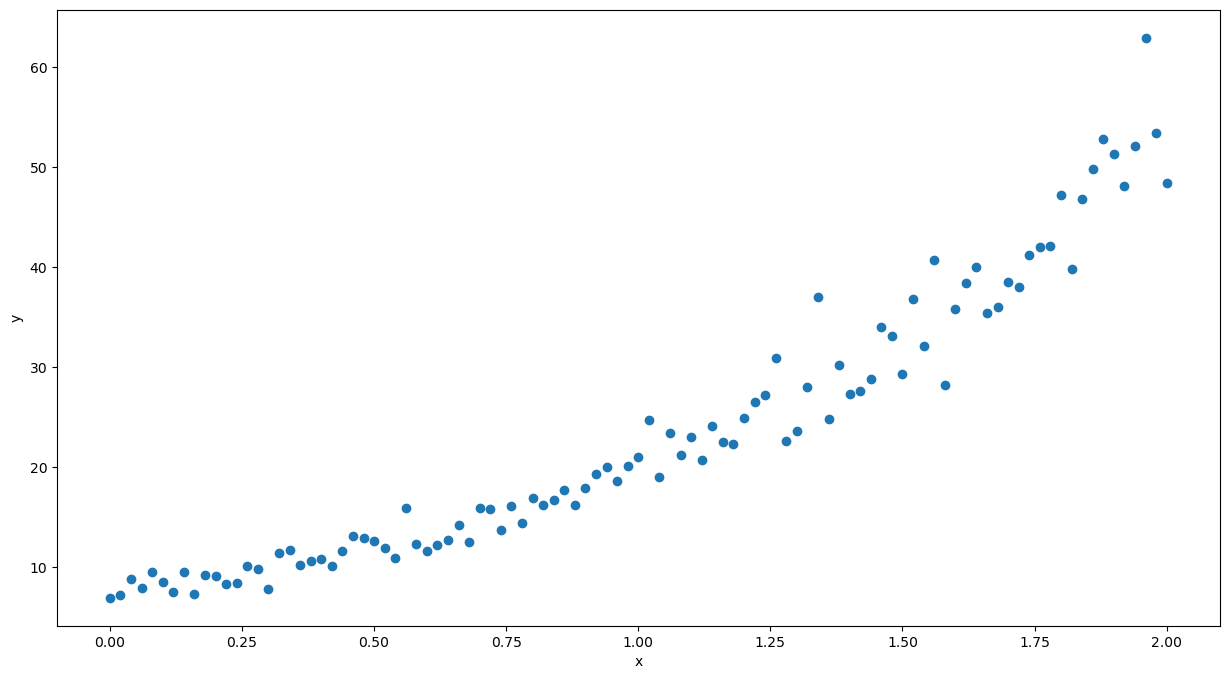

In [18]:
# plot 6
x = np.linspace(0, 2, 101)
y = np.exp(2 + x + rng.normal(scale=0.1, size=101))
plt.scatter(x, y); plt.xlabel("x"); plt.ylabel("y");

Here the model is
$$ y_i = \exp(a + b x_i + \epsilon_i) , $$
and so
$$ \log(y_i) = a + b x_i + \epsilon_i . $$

## Exercise:

Suppose the output of viruses $x$ hours after infection is
$$ y = \exp(a + bx + \epsilon), $$
where $\epsilon \sim \text{Normal}(0, \sigma)$.
Estimate $a$, $b$, and $\sigma$ using the following data:

In [19]:
x = np.array([28., 67.,  7., 47., 15., 65., 29., 21., 49., 41., 56.,  1., 32.,
        25., 49., 27., 40., 54., 22.,  9.])
y = np.array([ 32., 119.,   9.,  90.,  18., 107.,  23.,  14.,  56.,  40.,  85.,
         8.,  42.,  19.,  48.,  30.,  38., 110.,  27.,   8.])

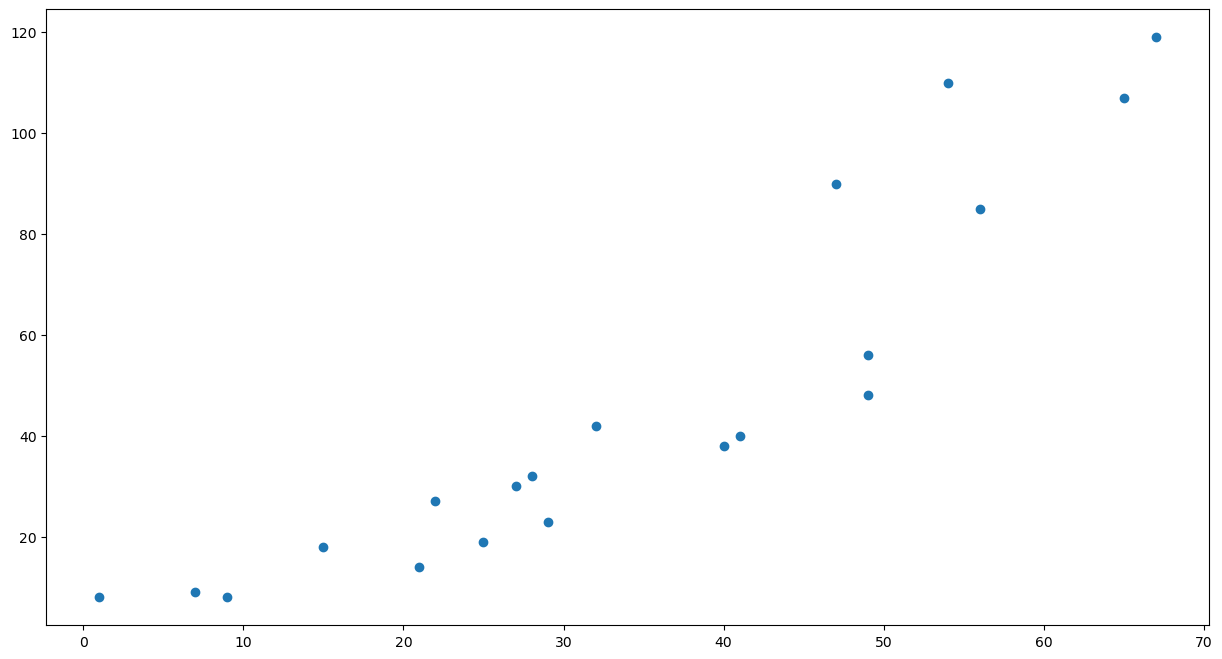

In [20]:
fig, ax = plt.subplots()

ax.scatter(x, y);

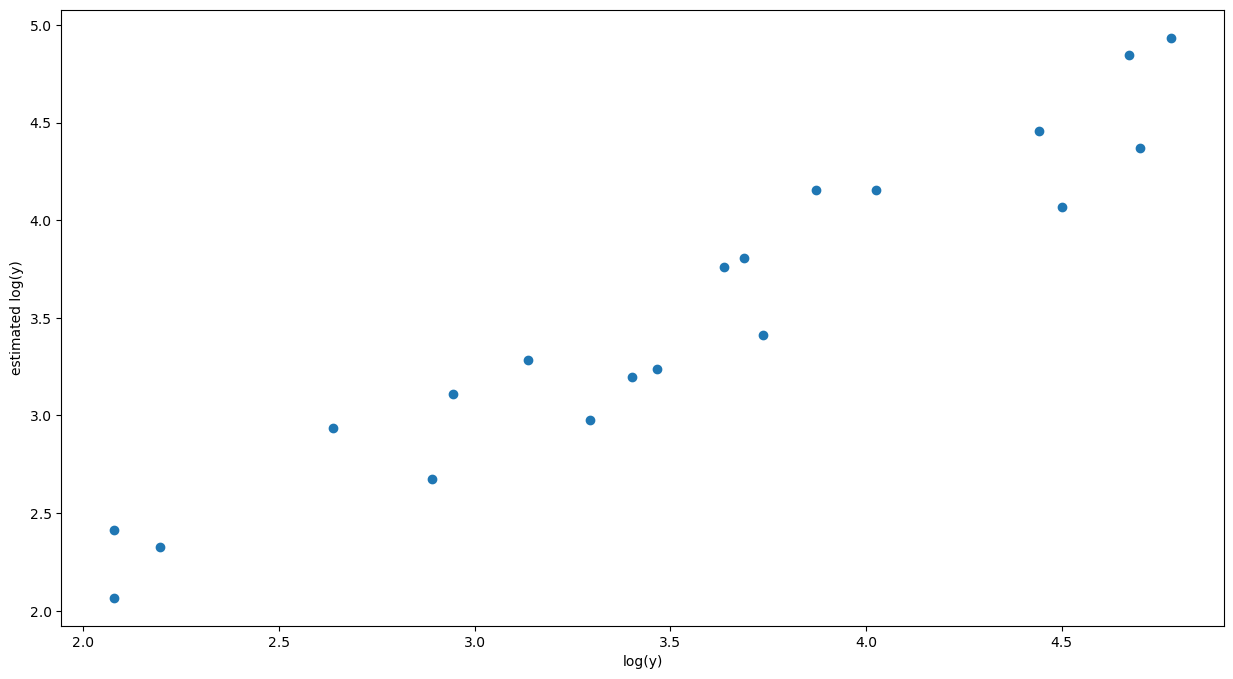

In [22]:
log_y = np.log(y)
b_hat = np.corrcoef(log_y, x)[0,1] * np.std(log_y, ddof=1) / np.std(x, ddof=1)
a_hat = np.mean(log_y) - b_hat * np.mean(x)
log_y_hat = a_hat + b_hat * x

fig, ax = plt.subplots()
ax.scatter(log_y, log_y_hat);
ax.set_xlabel("log(y)"); ax.set_ylabel("estimated log(y)");

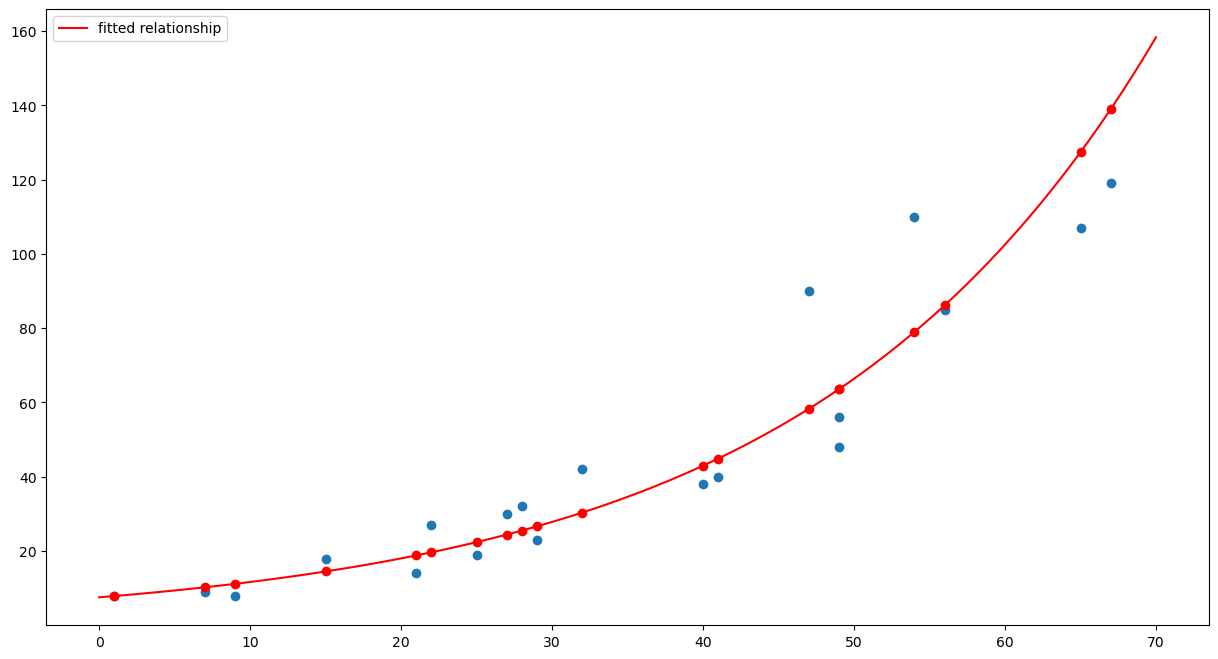

In [25]:
fig, ax = plt.subplots()
xx = np.linspace(0, 70, 101)
yy = np.exp(a_hat + b_hat * xx)

ax.scatter(x, y);
ax.scatter(x, np.exp(log_y_hat), c='red');
ax.plot(xx, yy, c='red', label='fitted relationship')
ax.legend()

In [26]:
a_hat, b_hat

(np.float64(2.0233605030174413), np.float64(0.04344533857803137))

In [28]:
np.exp(a_hat), np.exp(b_hat)

(np.float64(7.563700110146408), np.float64(1.0444029042038752))

In [32]:
sigma_hat = np.std(log_y_hat - np.log(y))
sigma_hat, np.exp(sigma_hat)

(np.float64(0.23322036464979462), np.float64(1.2626596942330999))

 The observed viral load (in ppm) is
 around 7.5 ppm at the time of the intial infection (estimated a=2.02);
 the increase of 4.3% per hour
 (estimated b=0.043).
 Actual observations differ from this with a standard deviation of around 26%.

# Nonlinear, for reals

Now suppose the output of viruses $x$ hours after infection is
$$ y = e^{a + bx} + \epsilon , $$
where $\epsilon \sim \text{Normal}(0, \sigma)$.

Can we solve this with a standard linear model?

**No.**

Solution: straightforward minimization,
with [scipy.optimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html),
for instance.

In [33]:
from scipy.optimize import least_squares

def resids(u):
    return y - np.exp(u[0] + u[1] * x)

ls_fit = least_squares(
    resids,
    x0=(1, 1),
)
ls_fit

     message: `ftol` termination condition is satisfied.
     success: True
      status: 2
         fun: [ 2.462e+00 -6.009e+00 ...  3.341e+00 -6.627e+00]
           x: [ 2.350e+00  3.699e-02]
        cost: 1457.0070960833966
         jac: [[-2.954e+01 -8.271e+02]
               [-1.250e+02 -8.376e+03]
               ...
               [-2.366e+01 -5.205e+02]
               [-1.463e+01 -1.316e+02]]
        grad: [-1.209e-05  4.690e-01]
  optimality: 0.4689870746078668
 active_mask: [ 0.000e+00  0.000e+00]
        nfev: 76
        njev: 73

In [34]:
est_a, est_b = ls_fit['x']
y_hat = np.exp(est_a + est_b * x)

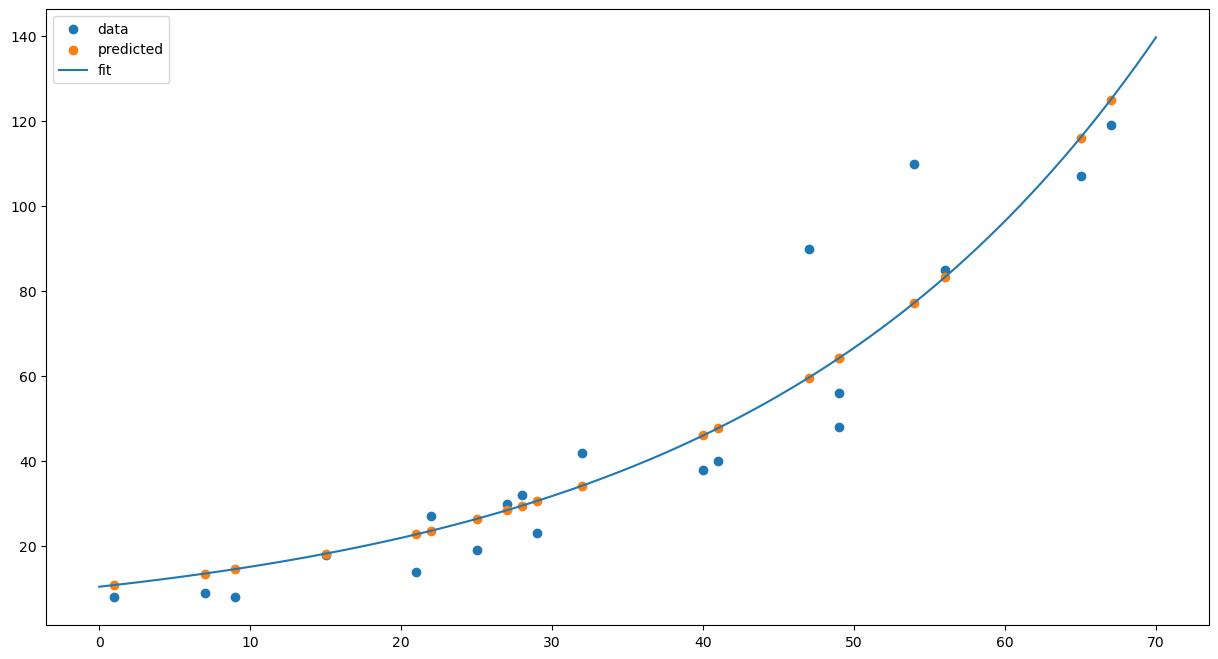

In [35]:
plt.scatter(x, y, label='data')
plt.scatter(x, y_hat, label='predicted')
xx = np.linspace(0, 70, 101)
plt.plot(xx, np.exp(est_a + est_b * xx), label='fit')
plt.legend();